15:50:35 - cmdstanpy - INFO - Chain [1] start processing
15:50:35 - cmdstanpy - INFO - Chain [1] done processing



=== En iyi Öğrenici Parametreleri (VAL'a göre) ===
RF : {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}  | VAL_MAE=19.55
XGB: {'n_estimators': 700, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 2.0, 'random_state': 42}  | VAL_MAE=19.91


15:50:36 - cmdstanpy - INFO - Chain [1] start processing
15:50:36 - cmdstanpy - INFO - Chain [1] done processing
15:50:36 - cmdstanpy - INFO - Chain [1] start processing
15:50:36 - cmdstanpy - INFO - Chain [1] done processing
15:50:36 - cmdstanpy - INFO - Chain [1] start processing
15:50:36 - cmdstanpy - INFO - Chain [1] done processing
15:50:36 - cmdstanpy - INFO - Chain [1] start processing
15:50:36 - cmdstanpy - INFO - Chain [1] done processing



=== EXOG Best-MAE Meta ===
- orders: method=prophet, MAE=89.79, RMSE=104.61, MAPE=57.15%
- stock: method=ets, MAE=61.02, RMSE=86.76, MAPE=114.59%

=== Sonuç Özeti — Best-MAE vs Ensemble ===
Split Strategy           Model    MAE   RMSE  MAPE
  VAL        -     RF (direct)  19.55    NaN   NaN
  VAL        -    XGB (direct)  19.91    NaN   NaN
 TEST Best-MAE  RF (recursive) 114.58 127.77 60.87
 TEST Best-MAE XGB (recursive) 118.54 130.86 63.76
 TEST Ensemble  RF (recursive)  60.64  69.15 38.97
 TEST Ensemble XGB (recursive)  64.84  73.89 42.40


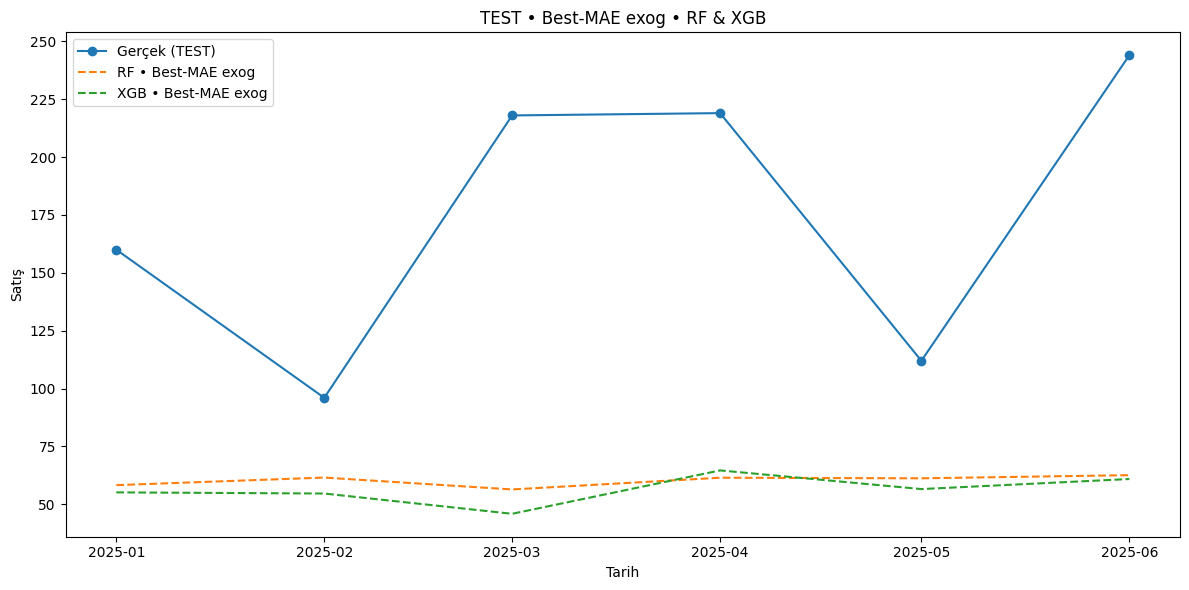

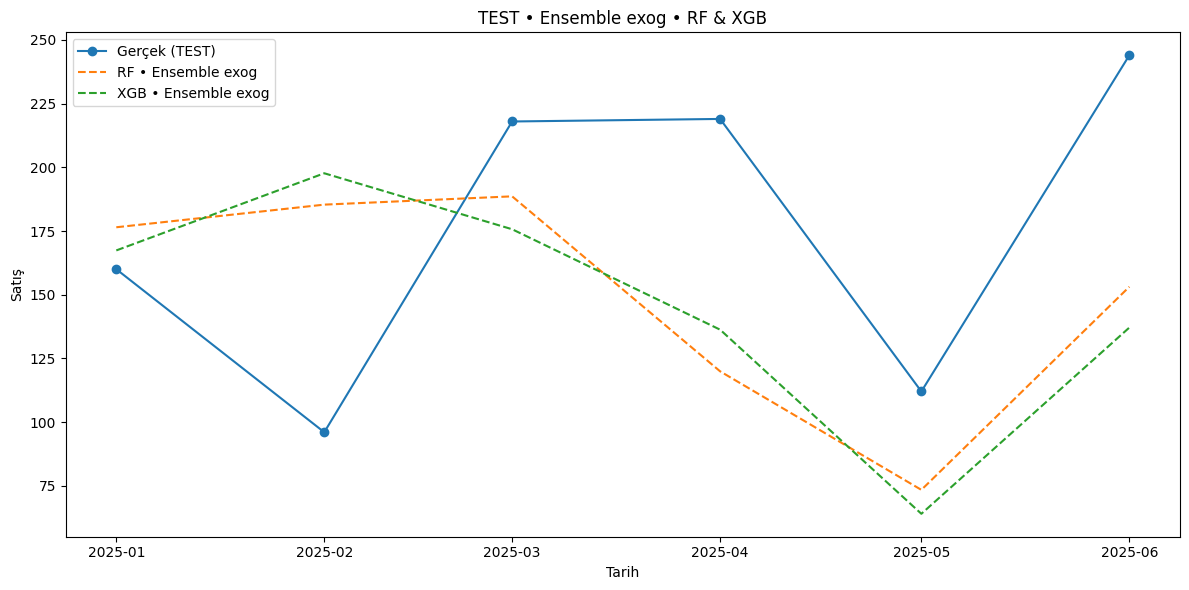

In [7]:
# ==============================================================
# Exog Stratejileri: (1) Best-MAE, (2) Ensemble(Prophet+SARIMA+ETS)
# Öğreniciler: RandomForest & XGBoost (VAL üzerinde HP arama)
# Özellikler: orders, stock, orders_lag1/3, stock_lag1/3, y_lag1, orders_ratio, month, year
# Recursive TEST (2025-01..07) ileri tahmin
# ==============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------------ Config ------------------
CSV_PATH   = "veri_matrisi_final_sales_orders_stock_calendar_lags_fx.csv"

TRAIN_END  = pd.Timestamp("2024-12-01")
#TRAIN_END  = pd.Timestamp("2025-07-01")
#VAL_START  = pd.Timestamp("2024-07-01")
#VAL_END    = pd.Timestamp("2024-12-01")
VAL_START  = pd.Timestamp("2025-01-01")
VAL_END    = pd.Timestamp("2025-06-01")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END   = pd.Timestamp("2025-06-01")

RANDOM_STATE = 42
EXOG_VAL_H   = 6  # exog yöntem backtest ufku (ay)

FEATURES = [
    "orders","stock",
    "orders_lag1","orders_lag3",
    "stock_lag1","stock_lag3",
    "y_lag1",
    "orders_ratio",
    "month","year",
]

# ------------------ Utilities ------------------
def mae_rmse_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(y_true == 0, 1, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape

def ensure_ms_freq(df):
    d = df.copy().sort_values("ds")
    d["ds"] = d["ds"].dt.to_period("M").dt.to_timestamp(how="start")
    d = d.set_index("ds").sort_index()
    d.index = pd.DatetimeIndex(d.index, freq="MS")
    return d.reset_index()

def rolling_impute_3m(s: pd.Series) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    roll = x.rolling(window=3, center=True, min_periods=1).mean()
    x = x.where(~x.isna(), roll)
    x = x.ffill().bfill()
    return x

def add_calendar(df):
    d = df.copy()
    d["year"]  = d["ds"].dt.year
    d["month"] = d["ds"].dt.month
    return d

def build_lags_minimal(df):
    d = df.copy()
    if "orders" in d.columns and "stock" in d.columns:
        d["orders_ratio"] = d["orders"] / d["stock"].replace(0, np.nan)
    if "y" in d.columns:
        d["y_lag1"] = d["y"].shift(1)
    if "orders" in d.columns:
        d["orders_lag1"] = d["orders"].shift(1)
        d["orders_lag3"] = d["orders"].shift(3)
    if "stock" in d.columns:
        d["stock_lag1"] = d["stock"].shift(1)
        d["stock_lag3"] = d["stock"].shift(3)
    return d

def prep_features(df_in):
    d = add_calendar(df_in)
    d = build_lags_minimal(d)
    # imputasyon: orders/stock
    for col in ["orders","stock"]:
        if col in d.columns:
            d[col] = rolling_impute_3m(d[col])
    # lag & ratio temizliği
    for col in ["orders_lag1","orders_lag3","stock_lag1","stock_lag3","y_lag1","orders_ratio"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce").ffill().bfill().fillna(0.0)
    for c in FEATURES:
        if c not in d.columns:
            d[c] = 0.0
    d = d.replace([np.inf, -np.inf], np.nan).fillna(0)
    return d

# ------------------ Univariate fit/predict helpers ------------------
def fit_prophet(train_df, value_col):
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
    m.fit(train_df.rename(columns={value_col:"y"}))
    return m

def forecast_prophet(model, steps):
    fut = model.make_future_dataframe(periods=steps, freq="MS")
    fc  = model.predict(fut)[["ds","yhat"]].tail(steps)
    return fc.rename(columns={"yhat":"yhat"})

def fit_sarima(train_df, value_col, order=(1,1,1), seasonal_order=(1,1,1,12)):
    y = train_df.set_index("ds")[value_col]
    y.index.freq = "MS"
    res = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return res

def forecast_sarima(model, steps, future_idx):
    pred = model.get_forecast(steps=steps).predicted_mean
    return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), "yhat": pred.values})

def fit_ets(train_df, value_col, trend="add", seasonal="add", seasonal_periods=12):
    y = train_df.set_index("ds")[value_col]
    y.index.freq = "MS"
    ets = ExponentialSmoothing(y, trend=trend, seasonal=seasonal,
                               seasonal_periods=seasonal_periods if seasonal else None).fit(optimized=True)
    return ets

def forecast_ets(model, steps, future_idx):
    pred = model.forecast(steps)
    return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), "yhat": pred.values})

# ------------------ Exog: Best-MAE seçim ------------------
def select_and_forecast_exog_best_mae(df_all, col_name, future_idx, val_h=EXOG_VAL_H):
    s = df_all[["ds", col_name]].dropna().sort_values("ds")
    if len(s) < val_h + 6:
        # veri kısa ise sabit tut
        out = pd.DataFrame({"ds": future_idx, col_name: s[col_name].iloc[-1] if len(s) else 0.0})
        out[col_name] = rolling_impute_3m(out[col_name])
        return out, {"method":"none", "mae":None, "rmse":None, "mape":None}

    cut = s["ds"].max() - pd.DateOffset(months=val_h-1)
    train = s[s["ds"] < cut]
    val   = s[s["ds"] >= cut]
    steps = len(val)

    # Prophet
    try:
        mp = fit_prophet(train, col_name)
        fcp = forecast_prophet(mp, steps)
        mae_p, rmse_p, mape_p = mae_rmse_mape(val[col_name].values, fcp["yhat"].values)
    except Exception:
        mp, mae_p, rmse_p, mape_p = None, np.inf, np.inf, np.inf

    # SARIMA
    try:
        ms = fit_sarima(train, col_name)
        fcs = forecast_sarima(ms, steps, val["ds"].values)
        mae_s, rmse_s, mape_s = mae_rmse_mape(val[col_name].values, fcs["yhat"].values)
    except Exception:
        ms, mae_s, rmse_s, mape_s = None, np.inf, np.inf, np.inf

    # ETS
    try:
        me = fit_ets(train, col_name, trend="add", seasonal="add", seasonal_periods=12)
        fce = forecast_ets(me, steps, val["ds"].values)
        mae_e, rmse_e, mape_e = mae_rmse_mape(val[col_name].values, fce["yhat"].values)
    except Exception:
        me, mae_e, rmse_e, mape_e = None, np.inf, np.inf, np.inf

    scores = {
        "prophet": (mae_p, rmse_p, mape_p, mp),
        "sarima" : (mae_s, rmse_s, mape_s, ms),
        "ets"    : (mae_e, rmse_e, mape_e, me),
    }
    best_method = min(scores.keys(), key=lambda k: scores[k][0])  # MAE en düşük
    mae_b, rmse_b, mape_b, model_b = scores[best_method]

    # Şimdi tüm seriyi (son tarihe kadar) kullanarak BEST modeli TEST ufkuna kur/forecast et
    full_train = s.copy()
    steps_test = len(future_idx)
    if best_method == "prophet":
        mfull = fit_prophet(full_train, col_name)
        fc    = forecast_prophet(mfull, steps_test)
        out   = fc.copy()
    elif best_method == "sarima":
        mfull = fit_sarima(full_train, col_name)
        out   = forecast_sarima(mfull, steps_test, future_idx)
    else:
        mfull = fit_ets(full_train, col_name, trend="add", seasonal="add", seasonal_periods=12)
        out   = forecast_ets(mfull, steps_test, future_idx)

    out = out.rename(columns={"yhat": col_name})[["ds", col_name]]
    out[col_name] = rolling_impute_3m(out[col_name])
    meta = {"method": best_method, "mae": mae_b, "rmse": rmse_b, "mape": mape_b}
    return out, meta

# ------------------ Exog: Ensemble (basit ortalama) ------------------
def forecast_exog_ensemble(df_all, col_name, future_idx):
    s = df_all[["ds", col_name]].dropna().sort_values("ds")
    if s.empty:
        out = pd.DataFrame({"ds": future_idx, col_name: 0.0})
        return out

    steps = len(future_idx)

    # Prophet
    try:
        mp  = fit_prophet(s, col_name)
        fcp = forecast_prophet(mp, steps).rename(columns={"yhat":"p"})
    except Exception:
        fcp = pd.DataFrame({"ds": future_idx, "p": np.nan})

    # SARIMA
    try:
        ms  = fit_sarima(s, col_name)
        fcs = forecast_sarima(ms, steps, future_idx).rename(columns={"yhat":"s"})
    except Exception:
        fcs = pd.DataFrame({"ds": future_idx, "s": np.nan})

    # ETS
    try:
        me  = fit_ets(s, col_name, trend="add", seasonal="add", seasonal_periods=12)
        fce = forecast_ets(me, steps, future_idx).rename(columns={"yhat":"e"})
    except Exception:
        fce = pd.DataFrame({"ds": future_idx, "e": np.nan})

    out = pd.DataFrame({"ds": future_idx})
    out = out.merge(fcp, on="ds", how="left").merge(fcs, on="ds", how="left").merge(fce, on="ds", how="left")
    out[col_name] = out[["p","s","e"]].mean(axis=1, skipna=True)
    # Eğer hepsi NaN ise son gözlemi sabitle
    if out[col_name].isna().all():
        last = s[col_name].iloc[-1]
        out[col_name] = last
    out[col_name] = rolling_impute_3m(out[col_name])
    return out[["ds", col_name]]

def build_future_exog_best_mae(df_all, future_idx):
    out = pd.DataFrame({"ds": future_idx})
    meta = {}
    for col in ["orders","stock"]:
        if col in df_all.columns:
            fc, m = select_and_forecast_exog_best_mae(df_all, col, future_idx, val_h=EXOG_VAL_H)
            out = out.merge(fc, on="ds", how="left")
            meta[col] = m
        else:
            out[col] = 0.0
            meta[col] = {"method":"none", "mae":None, "rmse":None, "mape":None}
    for c in ["orders","stock"]:
        out[c] = rolling_impute_3m(out[c])
    return out, meta

def build_future_exog_ensemble(df_all, future_idx):
    out = pd.DataFrame({"ds": future_idx})
    for col in ["orders","stock"]:
        if col in df_all.columns:
            fc = forecast_exog_ensemble(df_all, col, future_idx)
            out = out.merge(fc, on="ds", how="left")
        else:
            out[col] = 0.0
    for c in ["orders","stock"]:
        out[c] = rolling_impute_3m(out[c])
    return out

# ------------------ Learners: HP search on VAL ------------------
def optimize_rf(train_df, val_df):
    grid = {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 8, 12],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
    }
    best, best_mae = None, np.inf
    for n in grid["n_estimators"]:
        for md in grid["max_depth"]:
            for mss in grid["min_samples_split"]:
                for msl in grid["min_samples_leaf"]:
                    params = dict(n_estimators=n, max_depth=md, min_samples_split=mss,
                                  min_samples_leaf=msl, random_state=RANDOM_STATE, n_jobs=-1)
                    mdl = RandomForestRegressor(**params).fit(train_df[FEATURES], train_df["y"])
                    pred = mdl.predict(val_df[FEATURES])
                    mae = mae_rmse_mape(val_df["y"], pred)[0]
                    if mae < best_mae:
                        best_mae, best = mae, (params, mdl)
    return best[1], best[0], best_mae

def optimize_xgb(train_df, val_df):
    grid = {
        "n_estimators": [400, 700],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 4],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "reg_lambda": [1.0, 2.0],
    }
    best, best_mae = None, np.inf
    X_tr = train_df[FEATURES].to_numpy(); y_tr = train_df["y"].to_numpy()
    X_va = val_df[FEATURES].to_numpy();   y_va = val_df["y"].to_numpy()
    for n in grid["n_estimators"]:
        for lr in grid["learning_rate"]:
            for md in grid["max_depth"]:
                for ss in grid["subsample"]:
                    for cs in grid["colsample_bytree"]:
                        for rl in grid["reg_lambda"]:
                            params = dict(
                                n_estimators=n, learning_rate=lr, max_depth=md,
                                subsample=ss, colsample_bytree=cs, reg_lambda=rl,
                                random_state=RANDOM_STATE
                            )
                            mdl = XGBRegressor(**params)
                            mdl.fit(X_tr, y_tr, verbose=False)
                            pred = mdl.predict(X_va)
                            mae = mae_rmse_mape(y_va, pred)[0]
                            if mae < best_mae:
                                best_mae, best = mae, (params, mdl)
    return best[1], best[0], best_mae

# ------------------ Recursive forward ------------------
def recursive_forward_predict(model, x_cols, hist_df, future_exog, start_ds, end_ds):
    future_idx = pd.date_range(start_ds, end_ds, freq="MS")
    future_part = pd.DataFrame({"ds": future_idx}).merge(future_exog, on="ds", how="left")
    full = pd.concat([hist_df, future_part], ignore_index=True).sort_values("ds")

    preds = []
    for ds in future_idx:
        tmp = prep_features(full.copy())
        row = tmp.loc[tmp["ds"] == ds].copy()
        X = row[x_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
        y_hat = model.predict(X)[0]
        preds.append({"ds": ds, "yhat": y_hat})

        # Autoregressive güncelle
        full.loc[full["ds"] == ds, "y"] = y_hat

        # Exog güvenliği (opsiyonel)
        for c in ["orders","stock"]:
            if c in full.columns:
                full[c] = rolling_impute_3m(full[c])

    preds_df = pd.DataFrame(preds)
    used_future = full.loc[full["ds"].isin(future_idx)].copy()
    return preds_df, used_future

# ------------------ Load & prepare data ------------------
df = pd.read_csv(CSV_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
for c in ["y","orders","stock"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = ensure_ms_freq(df)
df = prep_features(df)

# Splits
mask_train_full = (df["ds"] <= TRAIN_END)
mask_val        = (df["ds"] >= VAL_START) & (df["ds"] <= VAL_END)
mask_test       = (df["ds"] >= TEST_START) & (df["ds"] <= TEST_END)

train_full = df.loc[mask_train_full].copy()
val_df     = df.loc[mask_val].copy()
test_df    = df.loc[mask_test].copy()

# ------------------ Optimize learners on VAL ------------------
rf_model,  rf_params,  rf_val_mae  = optimize_rf(train_full, val_df)
xgb_model, xgb_params, xgb_val_mae = optimize_xgb(train_full, val_df)

print("\n=== En iyi Öğrenici Parametreleri (VAL'a göre) ===")
print("RF :", rf_params,  f" | VAL_MAE={rf_val_mae:.2f}")
print("XGB:", xgb_params, f" | VAL_MAE={xgb_val_mae:.2f}")

# ------------------ Build EXOG for TEST (two strategies) ------------------
future_idx = pd.date_range(TEST_START, TEST_END, freq="MS")

exog_best, meta_best = build_future_exog_best_mae(df[["ds","orders","stock"]].copy(), future_idx)
exog_ens            = build_future_exog_ensemble(df[["ds","orders","stock"]].copy(), future_idx)

print("\n=== EXOG Best-MAE Meta ===")
for k,v in meta_best.items():
    if v["mae"] is None:
        print(f"- {k}: method=none")
    else:
        print(f"- {k}: method={v['method']}, MAE={v['mae']:.2f}, RMSE={v['rmse']:.2f}, MAPE={v['mape']:.2f}%")

# Recursive geçmiş (TRAIN+VAL gerçekleri)
hist_min = df[df["ds"] < TEST_START][["ds","y","orders","stock","month","year"]].copy()

# ------------------ Run: Best-MAE exog ------------------
pred_rf_best, _  = recursive_forward_predict(rf_model,  FEATURES, hist_min.copy(), exog_best, TEST_START, TEST_END)
pred_xgb_best, _ = recursive_forward_predict(xgb_model, FEATURES, hist_min.copy(), exog_best, TEST_START, TEST_END)

eval_rf_best  = test_df[["ds","y"]].merge(pred_rf_best,  on="ds", how="left")
eval_xgb_best = test_df[["ds","y"]].merge(pred_xgb_best, on="ds", how="left")

mae_rb, rmse_rb, mape_rb = mae_rmse_mape(eval_rf_best["y"],  eval_rf_best["yhat"])
mae_xb, rmse_xb, mape_xb = mae_rmse_mape(eval_xgb_best["y"], eval_xgb_best["yhat"])

# ------------------ Run: Ensemble exog ------------------
pred_rf_ens, _  = recursive_forward_predict(rf_model,  FEATURES, hist_min.copy(), exog_ens, TEST_START, TEST_END)
pred_xgb_ens, _ = recursive_forward_predict(xgb_model, FEATURES, hist_min.copy(), exog_ens, TEST_START, TEST_END)

eval_rf_ens  = test_df[["ds","y"]].merge(pred_rf_ens,  on="ds", how="left")
eval_xgb_ens = test_df[["ds","y"]].merge(pred_xgb_ens, on="ds", how="left")

mae_re, rmse_re, mape_re = mae_rmse_mape(eval_rf_ens["y"],  eval_rf_ens["yhat"])
mae_xe, rmse_xe, mape_xe = mae_rmse_mape(eval_xgb_ens["y"], eval_xgb_ens["yhat"])

# ------------------ Summary ------------------
res = pd.DataFrame([
    {"Split":"VAL",  "Strategy":"-",        "Model":"RF (direct)",  "MAE":rf_val_mae},
    {"Split":"VAL",  "Strategy":"-",        "Model":"XGB (direct)", "MAE":xgb_val_mae},
    {"Split":"TEST", "Strategy":"Best-MAE", "Model":"RF (recursive)",  "MAE":mae_rb, "RMSE":rmse_rb, "MAPE":mape_rb},
    {"Split":"TEST", "Strategy":"Best-MAE", "Model":"XGB (recursive)", "MAE":mae_xb, "RMSE":rmse_xb, "MAPE":mape_xb},
    {"Split":"TEST", "Strategy":"Ensemble", "Model":"RF (recursive)",  "MAE":mae_re, "RMSE":rmse_re, "MAPE":mape_re},
    {"Split":"TEST", "Strategy":"Ensemble", "Model":"XGB (recursive)", "MAE":mae_xe, "RMSE":rmse_xe, "MAPE":mape_xe},
])
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("\n=== Sonuç Özeti — Best-MAE vs Ensemble ===")
print(res.to_string(index=False))

# ------------------ Plots ------------------
plt.figure(figsize=(12,6))
plt.plot(test_df["ds"], test_df["y"], "o-", label="Gerçek (TEST)")
plt.plot(eval_rf_best["ds"],  eval_rf_best["yhat"],  "--", label="RF • Best-MAE exog")
plt.plot(eval_xgb_best["ds"], eval_xgb_best["yhat"], "--", label="XGB • Best-MAE exog")
plt.title("TEST • Best-MAE exog • RF & XGB")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(test_df["ds"], test_df["y"], "o-", label="Gerçek (TEST)")
plt.plot(eval_rf_ens["ds"],  eval_rf_ens["yhat"],  "--", label="RF • Ensemble exog")
plt.plot(eval_xgb_ens["ds"], eval_xgb_ens["yhat"], "--", label="XGB • Ensemble exog")
plt.title("TEST • Ensemble exog • RF & XGB")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.show()
